# DS 3000 - Assignment 4

**Student Name**: Gauri Rajesh

**Date**: 5/31/2025


### Submission Instructions
Submit this `ipynb` file to canvas.

The `ipynb` format stores outputs from the last time you ran the notebook.  (When you open a notebook it has the figures and outputs of the last time you ran it too).  To ensure that your submitted `ipynb` file represents your latest code, make sure to give a fresh run `Kernel > Restart & Run All` just before uploading the `ipynb` file to Canvas.

### Academic Integrity

**Writing your homework is an individual effort.**  You may discuss general python problems with other students but under no circumstances should you observe another student's code which was written for this assignment, from this year or past years.  Pop into office hours or DM us in MS Teams if you have a specific question about your work or if you would like another pair of eyes or talk through your code.

Don't forget to cite websites which helped you solve a problem in a unique way.  You can do this in markdown near the code or with a simple one-line comment. You do not need to cite the official python documentation.

**Documentation / style counts for credit**  Please refer to the Pep-8 style, to improve the readability and consistency of your Python code. For more information, read the following article [How to Write Beautiful Python Code With PEP 8](https://realpython.com/python-pep8/) or ask your TA's for tips.

**NOTE:<span style='color:red'> Write python expressions to answer ALL questions below and ensure that you use the `print()` function to display the output.</span>** Each question should be answered in a new code cell. For example, your solution for question 1.1 should be in a different code cell from your solution for question 1.2.

## Question 1: 

TODO: (3 pts) Load the data into a dataframe. Inspect the data and perform at least one type of data preparation.


In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.linear_model import LinearRegression
from sklearn.metrics import r2_score
import numpy as np

# load data
df = pd.read_csv("Air_Traffic_Passenger_Statistics.csv")

# inspect head
df.head()

,Activity Period,Activity Period Start Date,Operating Airline,Operating Airline IATA Code,Published Airline,Published Airline IATA Code,GEO Summary,GEO Region,Activity Type Code,Price Category Code,Terminal,Boarding Area,Passenger Count,data_as_of,data_loaded_at
0,199907,1999/07/01,ATA Airlines,TZ,ATA Airlines,TZ,Domestic,US,Deplaned,Low Fare,Terminal 1,B,31432,2023/12/21 12:05:27 AM,2024/01/20 07:02:35 AM
1,199907,1999/07/01,ATA Airlines,TZ,ATA Airlines,TZ,Domestic,US,Enplaned,Low Fare,Terminal 1,B,31353,2023/12/21 12:05:27 AM,2024/01/20 07:02:35 AM
2,199907,1999/07/01,ATA Airlines,TZ,ATA Airlines,TZ,Domestic,US,Thru / Transit,Low Fare,Terminal 1,B,2518,2023/12/21 12:05:27 AM,2024/01/20 07:02:35 AM
3,199907,1999/07/01,Aeroflot Russian International Airlines,NaN,Aeroflot Russian International Airlines,NaN,International,Europe,Deplaned,Other,Terminal 2,D,1324,2023/12/21 12:05:27 AM,2024/01/20 07:02:35 AM
4,199907,1999/07/01,Aeroflot Russian International Airlines,NaN,Aeroflot Russian International Airlines,NaN,International,Europe,Enplaned,Other,Terminal 2,D,1198,2023/12/21 12:05:27 AM,2024/01/20 07:02:35 AM


In [2]:
# inspect the dimensions
print(f"There are {df.shape[0]} rows and {df.shape[1]} columns.")

# inspect data types
df.info()

There are 35172 rows and 15 columns.
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 35172 entries, 0 to 35171
Data columns (total 15 columns):
 #   Column                       Non-Null Count  Dtype 
---  ------                       --------------  ----- 
 0   Activity Period              35172 non-null  int64 
 1   Activity Period Start Date   35172 non-null  object
 2   Operating Airline            35172 non-null  object
 3   Operating Airline IATA Code  34856 non-null  object
 4   Published Airline            35172 non-null  object
 5   Published Airline IATA Code  34856 non-null  object
 6   GEO Summary                  35172 non-null  object
 7   GEO Region                   35172 non-null  object
 8   Activity Type Code           35172 non-null  object
 9   Price Category Code          35172 non-null  object
 10  Terminal                     35172 non-null  object
 11  Boarding Area                35172 non-null  object
 12  Passenger Count              35172 non-null  int64 

Operating Airline, Operating Airline IATA Code, Published Airline, Published Airline IATA Code, GEO Summary, GEO Region, Activity Type Code, Price Category Code, Terminal, and Boarding Area will be converted to categorical variables as they represent labels or have a finite set of values based on the data dictionary.  Activity Period Start Date, data_as_of, and data_loaded_at will be converted to datetime.

In [3]:
# convert variables to suitable types
df['Operating Airline'] = df['Operating Airline'].astype('category')
df['Operating Airline IATA Code'] = df['Operating Airline IATA Code'].astype('category')
df['Published Airline'] = df['Published Airline'].astype('category')
df['Published Airline IATA Code'] = df['Published Airline IATA Code'].astype('category')
df['GEO Summary'] = df['GEO Summary'].astype('category')
df['GEO Region'] = df['GEO Region'].astype('category')
df['Activity Type Code'] = df['Activity Type Code'].astype('category')
df['Price Category Code'] = df['Price Category Code'].astype('category')
df['Terminal'] = df['Terminal'].astype('category')
df['Boarding Area'] = df['Boarding Area'].astype('category')

df['Activity Period Start Date'] = df['Activity Period Start Date'] = pd.to_datetime(df['Activity Period Start Date'], format='%Y/%m/%d')
df['data_as_of'] = df['data_as_of'] = pd.to_datetime(df['data_as_of'], format='%Y/%m/%d %I:%M:%S %p')
df['data_loaded_at'] = df['data_loaded_at'] = pd.to_datetime(df['data_as_of'], format='%Y/%m/%d %I:%M:%S %p')

# verify changes
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 35172 entries, 0 to 35171
Data columns (total 15 columns):
 #   Column                       Non-Null Count  Dtype         
---  ------                       --------------  -----         
 0   Activity Period              35172 non-null  int64         
 1   Activity Period Start Date   35172 non-null  datetime64[ns]
 2   Operating Airline            35172 non-null  category      
 3   Operating Airline IATA Code  34856 non-null  category      
 4   Published Airline            35172 non-null  category      
 5   Published Airline IATA Code  34856 non-null  category      
 6   GEO Summary                  35172 non-null  category      
 7   GEO Region                   35172 non-null  category      
 8   Activity Type Code           35172 non-null  category      
 9   Price Category Code          35172 non-null  category      
 10  Terminal                     35172 non-null  category      
 11  Boarding Area                35172 non-nu

In [4]:
# percentage of missing values
df.isnull().mean()*100


# only specific time period of data used?
# all operating airlines are two letters?
# NaN in operating IATA and published IATA
# categorical: operating airline + IATA, published airline + IATA, GEO Summary, GEO Region, Activity Type Code, Price Category Code, Terminal, Boarding Area
# passenger count int

Activity Period                0.000000
Activity Period Start Date     0.000000
Operating Airline              0.000000
Operating Airline IATA Code    0.898442
Published Airline              0.000000
Published Airline IATA Code    0.898442
GEO Summary                    0.000000
GEO Region                     0.000000
Activity Type Code             0.000000
Price Category Code            0.000000
Terminal                       0.000000
Boarding Area                  0.000000
Passenger Count                0.000000
data_as_of                     0.000000
data_loaded_at                 0.000000
dtype: float64

In [5]:
# distribution of missing values in rows
df.isnull().sum(axis=1).sort_values(ascending=False).value_counts()

0    34856
2      316
Name: count, dtype: int64

Based on this information, missing data is not widespread since only a small percentage of rows have missing data.  Out of the rows with missing data, all of them have a missing Operating Airline IATA Code or Published Airline IATA Code.  Since a majority of the data does not contain missing values, rows with missing data will be deleted.

In [6]:
# remove rows with null values
df = df.dropna()

# verify changes
df.isnull().sum(axis=1).sort_values(ascending=False).value_counts()

0    34856
Name: count, dtype: int64

## Question 2: 
TODO: Determine which terminal has the most passenger traffic and visualize the results. Explain the graph.

The average number of passengers per month will be used to determine which terminal has the most traffic.  Since rows with missing data were deleted, this would be more appropriate than taking the total passenger counts across the dataset for each terminal

In [7]:
# group data by terminal and determine average passenger counts per month
passenger_traffic_df = df.groupby('Terminal', observed=True)['Passenger Count'].mean()
passenger_traffic_df.head()

Terminal
International    11426.526460
Other                7.000000
Terminal 1       35283.749691
Terminal 2       42557.725648
Terminal 3       89659.916865
Name: Passenger Count, dtype: float64

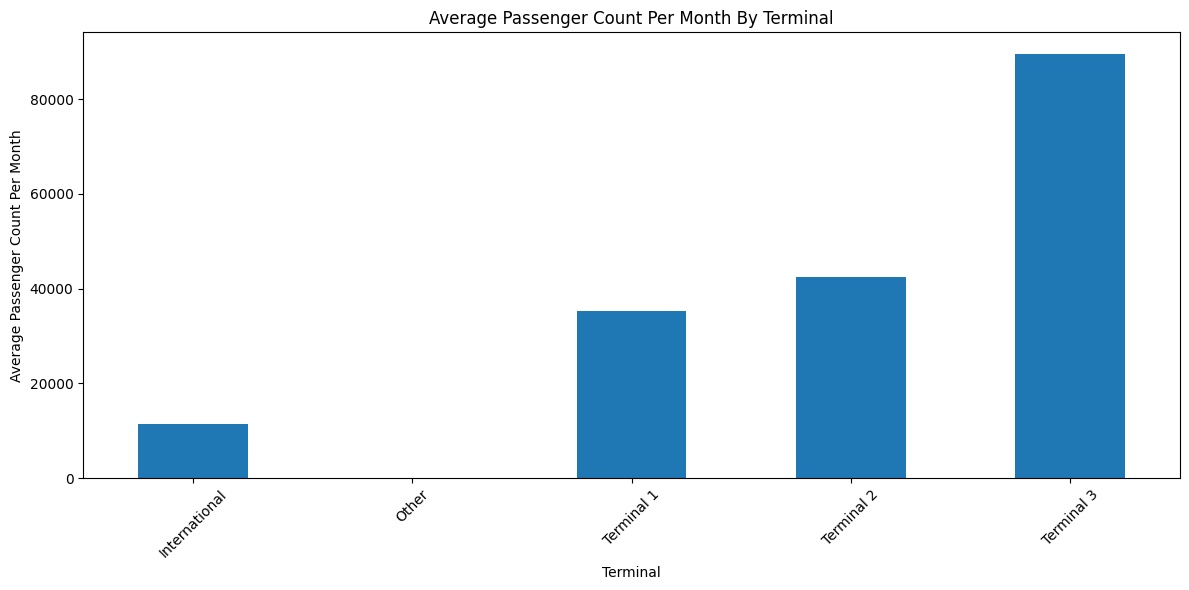

In [8]:

passenger_traffic_df.plot(kind='bar', figsize=(12, 6))
plt.title("Average Passenger Count Per Month By Terminal")
plt.xlabel("Terminal")
plt.ylabel("Average Passenger Count Per Month")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

Based on the visualization, Terminal 3 dominates in terms of average passenger count per month as it has 80,000 passengers per month.  Terminal 2 follows with over 40,000 passengers per month.  Other has a negligable amount of passengers per month on average compared to the other terminals.

## Question 3: 
TODO: Plot the annual domestic and international enplanement and deplanement using a line chart. Explain the patterns and discuss which years have the most and least passenger traffic.
Tip: It is recommended that you create two charts; chart #1 for the international travelers and Chart #2 for the domestic travelers. Then in each chart, visualize the number of passengers who enplaned and deplaned each year. The annual passenger enplanement and deplanement should be visualized using separate lines.

In [9]:
# filter data by domestic and international flights
annual_domestic_df = df[df['GEO Summary'].astype('string') == "Domestic"].copy()
annual_int_df = df[df['GEO Summary'].astype('string') == "International"].copy()

# group by activity type code
annual_domestic_en_df = annual_domestic_df[annual_domestic_df['Activity Type Code'].astype('string') == "Enplaned"].copy()
annual_domestic_de_df = annual_domestic_df[annual_domestic_df['Activity Type Code'].astype('string') == "Deplaned"].copy()

annual_int_en_df = annual_int_df[annual_int_df['Activity Type Code'].astype('string') == "Enplaned"].copy()
annual_int_de_df = annual_int_df[annual_int_df['Activity Type Code'].astype('string') == "Deplaned"].copy()

# add new column with year
annual_domestic_en_df.loc[:, 'Year'] = annual_domestic_en_df['Activity Period Start Date'].dt.year
annual_domestic_de_df.loc[:, 'Year'] = annual_domestic_de_df['Activity Period Start Date'].dt.year

annual_int_en_df.loc[:, 'Year'] = annual_int_en_df['Activity Period Start Date'].dt.year
annual_int_de_df.loc[:, 'Year'] = annual_int_de_df['Activity Period Start Date'].dt.year

# only keep relevant columns
annual_domestic_en_df1 = annual_domestic_en_df[['Year', 'Passenger Count']]
annual_domestic_de_df1 = annual_domestic_de_df[['Year', 'Passenger Count']]

annual_int_en_df1 = annual_int_en_df[['Year', 'Passenger Count']]
annual_int_de_df1 = annual_int_de_df[['Year', 'Passenger Count']]

# group by year to get sums of passenger counts
annual_domestic_en_df1 = annual_domestic_en_df1.groupby('Year', observed=True)['Passenger Count'].sum()
annual_domestic_de_df1 = annual_domestic_de_df1.groupby('Year', observed=True)['Passenger Count'].sum()

annual_int_en_df1 = annual_int_en_df1.groupby('Year', observed=True)['Passenger Count'].sum()
annual_int_de_df1 = annual_int_de_df1.groupby('Year', observed=True)['Passenger Count'].sum()

In [10]:
# merge enplanement and deplanement data frames
annual_domestic_merg_df1 = pd.merge(annual_domestic_en_df1, annual_domestic_de_df1, on='Year', how='inner', suffixes=('_Enplanement', '_Deplanement'))

annual_int_merg_df1 = pd.merge(annual_int_en_df1, annual_int_de_df1, on='Year', how='inner', suffixes=('_Enplanement', '_Deplanement'))

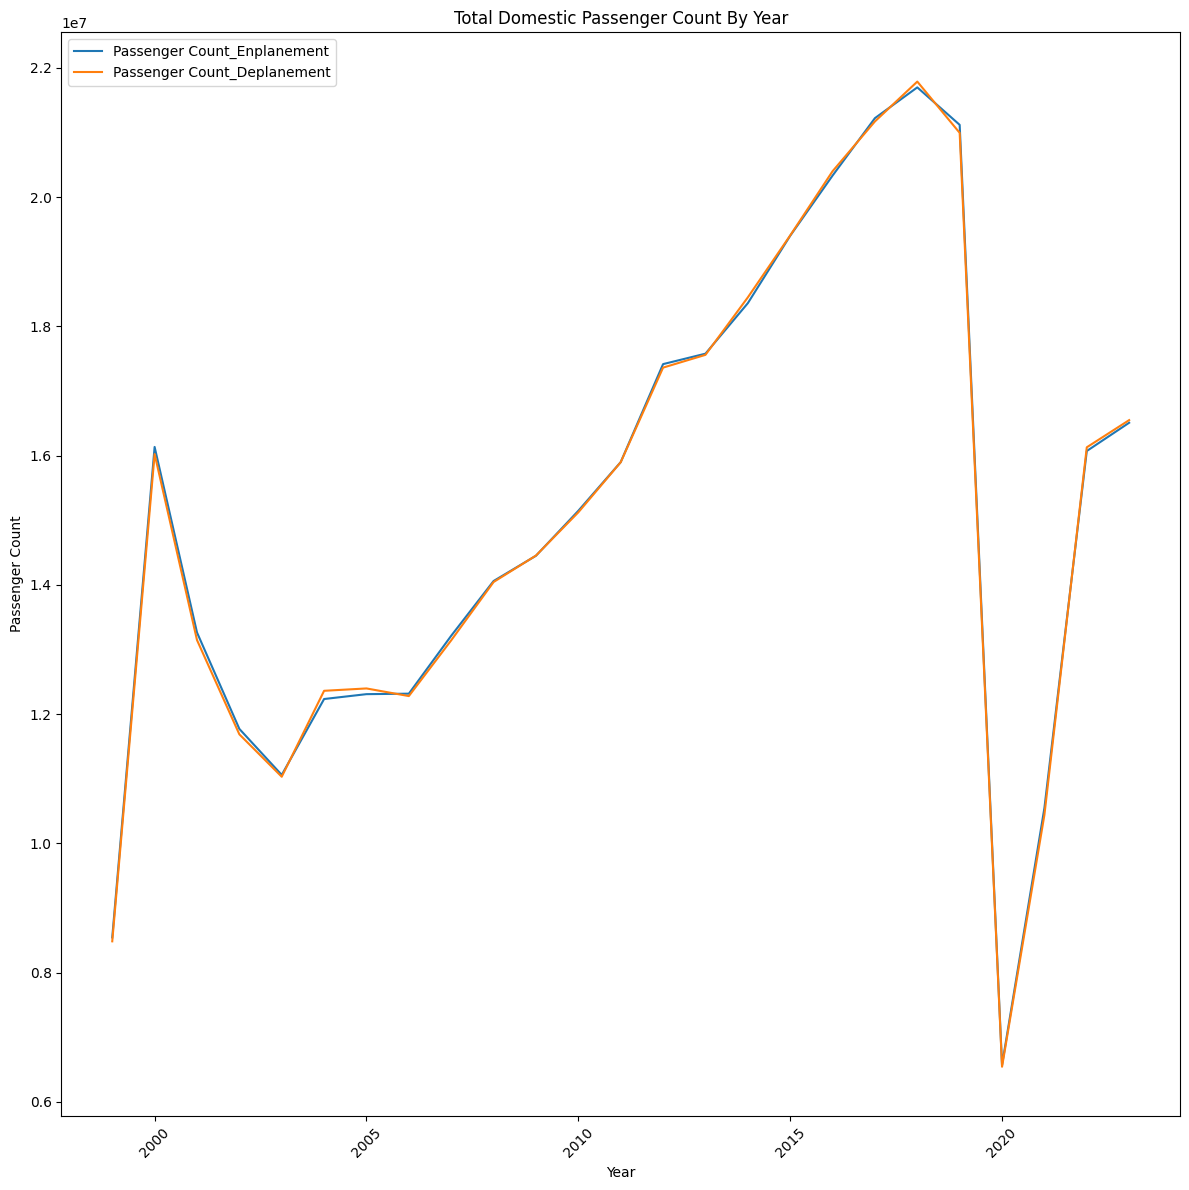

In [11]:
# visualize domestic enplanement and deplanement data by year
annual_domestic_merg_df1.plot(kind='line', figsize=(12, 12))
plt.title("Total Domestic Passenger Count By Year")
plt.xlabel("Year")
plt.ylabel("Passenger Count")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

Based on the visualization, 2016-2017 had the greatest amount of domestic passenger traffic with just under 22 million passengers.  Between 2003 and 2016, the total number of passengers steadily increased starting from 11 million.  The least amount of air traffic occured in 2020 with only about 6.5 million passengers, likely due to the global pandemic.  After 2020, the total number of passengers has steadily increased.

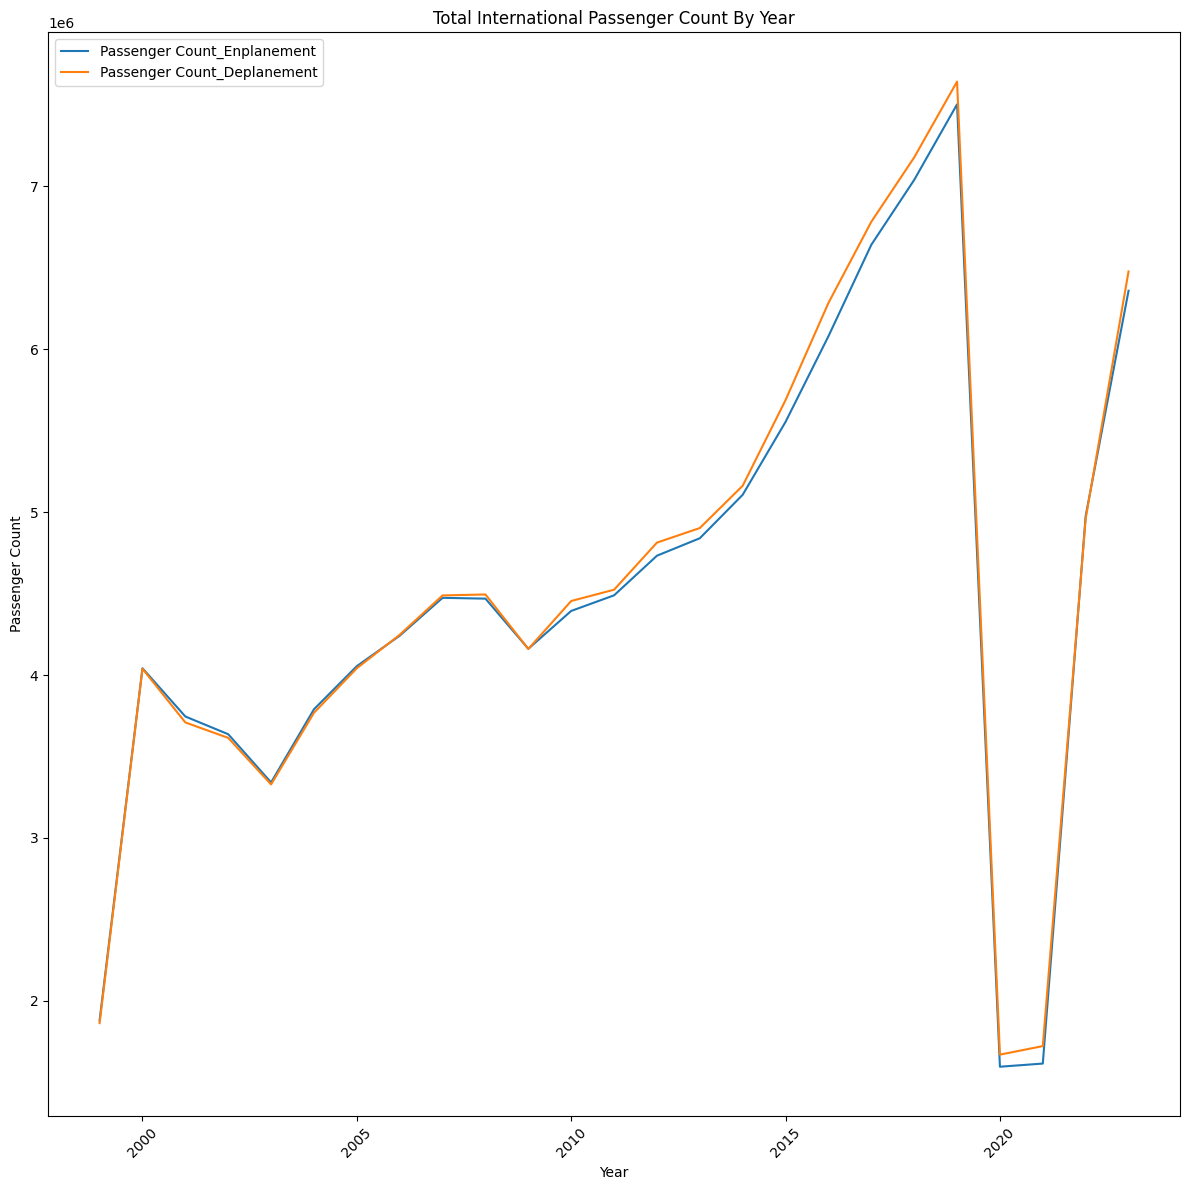

In [12]:
# visualize international enplanement and deplanement data by year
annual_int_merg_df1.plot(kind='line', figsize=(12, 12))
plt.title("Total International Passenger Count By Year")
plt.xlabel("Year")
plt.ylabel("Passenger Count")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

Based on the visualization, 2016-2017 had the greatest amount of international passenger traffic with just under 8 million passengers.  Between 2003 and 2016, the total number of passengers steadily increased starting from 3.5 million.  The least amount of air traffic occured in 2020 with only about 1 million passengers, likely due to the global pandemic.  After 2020, the total number of passengers has steadily increased.  Overall, domestic passenger air traffic is significantly greater than international passenger air traffic.  This indicates there are less passengers who travel internationally compared to domestically.

## Question 4: 
TODO: Demonstrate which airlines contributed to the most passenger traffic over the last 10 years and visualize the results? Are there changes in the top airlines each year? Ensure that you visualize the top 5 airlines and explain the patterns.

In [13]:
# add year column to new df
yearly_df = df.copy()
yearly_df.loc[:, 'Year'] = yearly_df['Activity Period Start Date'].dt.year

ten_year_traffic_data = {}

# group by year
for i in range(2014, 2024):
    # filter by current year
    curr_year_df = yearly_df[yearly_df['Year'].astype(int) == i]
    # add current year to dictionary
    ten_year_traffic_data[i] = curr_year_df

# group by airline and sum passenger counts; sort in descending order and only keep top 5 airlines
for key in ten_year_traffic_data:
    ten_year_traffic_data[key] = ten_year_traffic_data[key].groupby('Operating Airline', observed=True)[['Passenger Count']].sum().reset_index()
    ten_year_traffic_data[key] = ten_year_traffic_data[key].sort_values(by='Passenger Count', ascending=False).reset_index(drop=True)
    ten_year_traffic_data[key] = ten_year_traffic_data[key][:5]

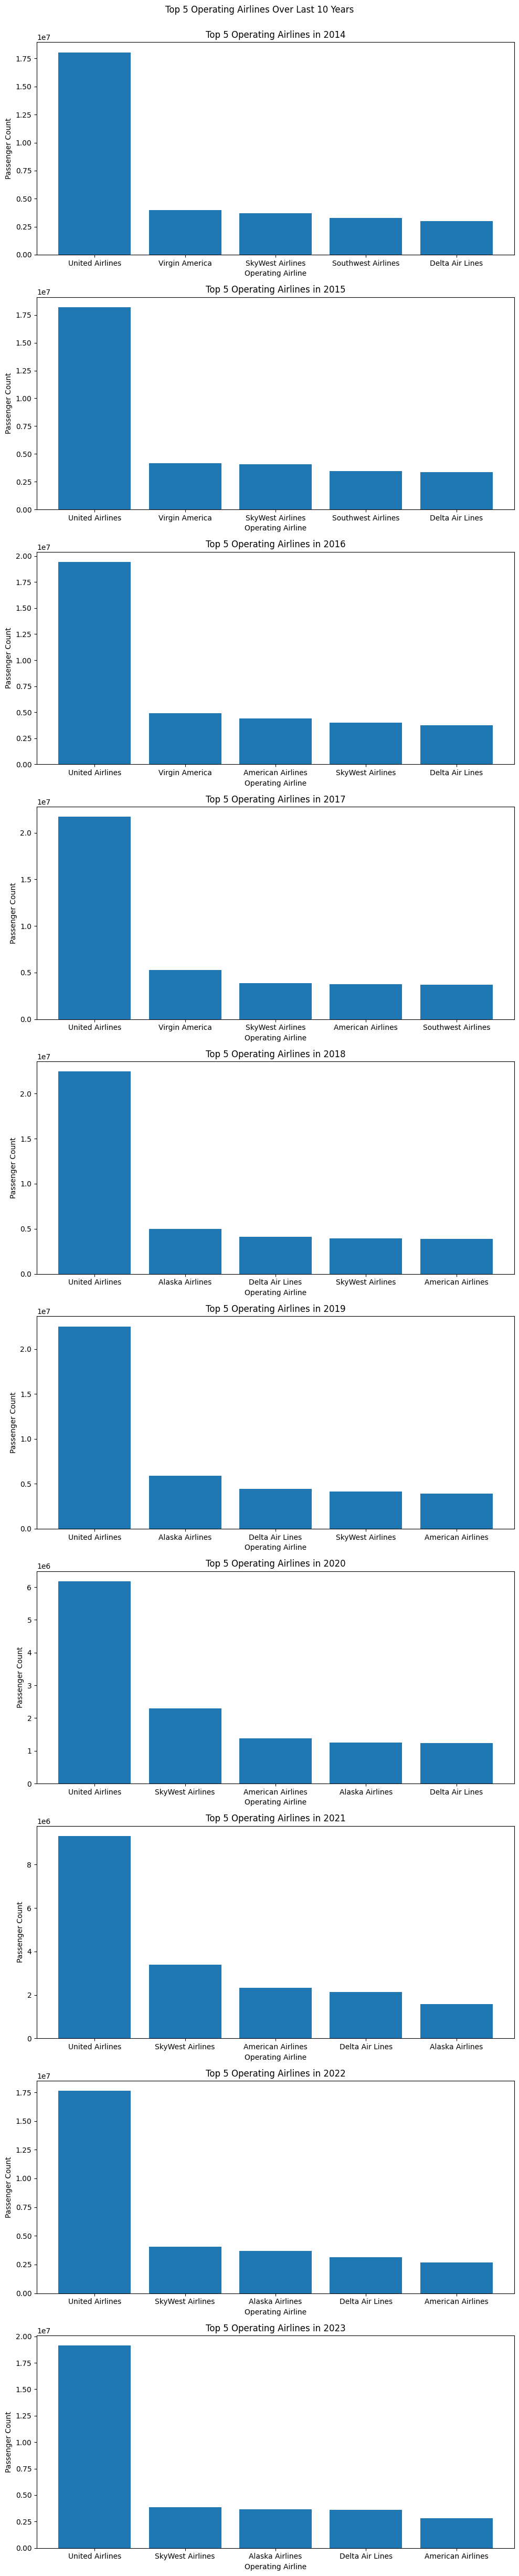

In [14]:
# visualize top airlines over last ten years
fig, axs = plt.subplots(10, figsize=(10, 50))
axs = axs.flatten()

plt.suptitle('Top 5 Operating Airlines Over Last 10 Years')
for i in range(2014, 2024):
    year_df = ten_year_traffic_data[i]
    axs[i - 2014].set_title(f'Top 5 Operating Airlines in {i}')
    axs[i - 2014].set_ylabel('Passenger Count')
    axs[i - 2014].set_xlabel('Operating Airline')
    axs[i - 2014].bar(year_df['Operating Airline'], year_df['Passenger Count'])
plt.tight_layout(rect=[0, 0, 1, 0.98])
plt.show()


### Airline Passenger Traffic By Year ###

#### 2014 ####
In 2014, the top airlines were United Airlines, Virgin America, SkyWest Airlines, Southwest Airlines, and Delta Air Lines in descending order.  United Airlines dominated in terms of total passenger count with just over 17.5 million passengers.  The other airlines had between 2.5 and 5 million passengers.
<br></br>

#### 2015 ####
In 2015, the top airlines were United Airlines, Virgin America, SkyWest Airlines, Southwest Airlines, and Delta Air Lines in descending order.  United Airlines dominated in terms of total passenger count with just over 17.5 million passengers.  The other airlines had between 2.5 and 5 million passengers.  The top airlines did not change from 2014 and the passenger counts did not change significantly either.
<br></br>

#### 2016 ####
In 2016, the top airlines were United Airlines, Virgin America, American Airlines, SkyWest Airlines, and Delta Air Lines in descending order.  United Airlines dominated in terms of total passenger count with just under 20 million passengers.  The other airlines had just under 5 million passengers.  The total number of passengers increased for United Airlines, American Airlines became the third operating airline with the most passenger traffic, and Southwest airlines was no longer in the top five airlines.
<br></br>

#### 2017 ####
In 2017, the top airlines were United Airlines, Virgin America, SkyWest Airlines, American Airlines, and Southwest in descending order.  United Airlines dominated in terms of total passenger count with over 20 million passengers.  The other airlines had between 4 and 5 million passengers.  The total number of passengers increased again for United Airlines, SkyWest Airlines swapped with American Airlines in terms of most passenger traffic, and Delta airlines was no longer in the top five airlines.
<br></br>

#### 2018 ####
In 2018, the top airlines were United Airlines, Alaska Airlines, Delta Air Lines, SkyWest Airlines, and American Airlines in descending order.  United Airlines dominated in terms of total passenger count with close to 22 million passengers.  The other airlines had between 4 and 5 million passengers.  The total number of passengers increased again for United Airlines, Alaska Airlines emerged as the operating airline with the second highest passenger traffic, Delta airlines reemerged with the third highest passenger traffic, and Southwest airlines was no longer in the top five airlines.
<br></br>

#### 2019 ####
In 2019, the top airlines were United Airlines, Alaska Airlines, Delta Air Lines, SkyWest Airlines, and American Airlines in descending order.  The total passenger counts and ordering of operating airlines in 2019 was not significantly different from 2018.
<br></br>

#### 2020 ####
In 2020, the top airlines were United Airlines, SkyWest Airlines, American Air Lines, Alaska Airlines, and Delta Airlines in descending order.  All airlines experienced lower levels of passenger traffic likely due to the global pandemic with United Airlines having just over 6 million passengers, SkyWest Airlines with just over 2 million passengers, and the other airlies having just over 1 million passengers.
<br></br>

#### 2021 ####
In 2021, the top airlines were United Airlines, SkyWest Airlines, American Air Lines, Delta Airlines, and Alaska Airlines in descending order.  All airlines experienced slight increases in passenger traffic with United Airlines having just under 10 million passengers, SkyWest Airlines with just over 3 million passengers, and the other airlies having just under 2 million passengers.
<br></br>

#### 2022 ####
<br></br>
In 2022, the top airlines were United Airlines, SkyWest Airlines, Alaska Airlines, Delta Airlines, and American Airlines in descending order.  All airlines experienced increases in passenger traffic with United Airlines having 17.5 million passengers and the other airlines having between 2.5 and 5 million passengers.  In 2022, the total passenger counts for airlines resembled the data just before 2020.

#### 2023 ####
<br></br>
In 2023, the top airlines were United Airlines, SkyWest Airlines, Alaska Airlines, Delta Airlines, and American Airlines in descending order.  Aside from United Airlines increasing to just under 20 million passengers, the data did not change significantly from 2022.

#### Overall Analysis ####
Over the last 10 years, the top operating airlines have not changed significantly.  The airlines with the most traffic have been United Airlines, Alaska Airlines, Southwest Airlines, Delta Airlines, American Airlines, SkyWest Airlines, and Virgin America.  United Airlines consistently dominated in terms of passenger traffic with between 17.5 and 22 million passengers.  The other airlines typically had 2.5 to 5 million passengers each year.  Aside from United Airlines, the ordering of the other four airlines did change in some years.  To name a few examples, in 2017 Delta Airlines was no longer in the top 5, in 2018 Southwest Airlines was no longer in the top 5, and in 2018 Alaska Airlines emerged as an operating airline with high levels of passenger traffic.  In 2020, the levels of passenger traffic signficantly decreased across all airlines likely due to the global pandemic.

## Question 5: ##
TODO: Extract data from 2003 to 2018 (inclusive), for all passengers who deplaned the aircraft in May e.g. May 2003, May 2004, May 2005 etc. Visualize the extracted data, using a line chart, and comment on the trend.

In [15]:
deplaned_in_may_df = yearly_df.copy()

# add month colum to data frame
deplaned_in_may_df.loc[:, 'Month'] = deplaned_in_may_df['Activity Period Start Date'].dt.month


# create filter for data frame
deplaned_in_may_filter = ((deplaned_in_may_df['Year'] >= 2003) 
                          & (deplaned_in_may_df['Year'] <= 2018)
                          & (deplaned_in_may_df['Month'] == 5)
                          & (deplaned_in_may_df['Activity Type Code'].astype('string') == "Deplaned"))

# apply filter and sum total deplanement passengers by month
deplaned_in_may_df = deplaned_in_may_df[deplaned_in_may_filter]
deplaned_in_may_df = deplaned_in_may_df.groupby(['Year', 'Month'], observed=True)['Passenger Count'].sum().reset_index()
deplaned_in_may_df.head()

,Year,Month,Passenger Count
0,2003,5,1104588
1,2004,5,1366267
2,2005,5,1420162
3,2006,5,1402609
4,2007,5,1511517


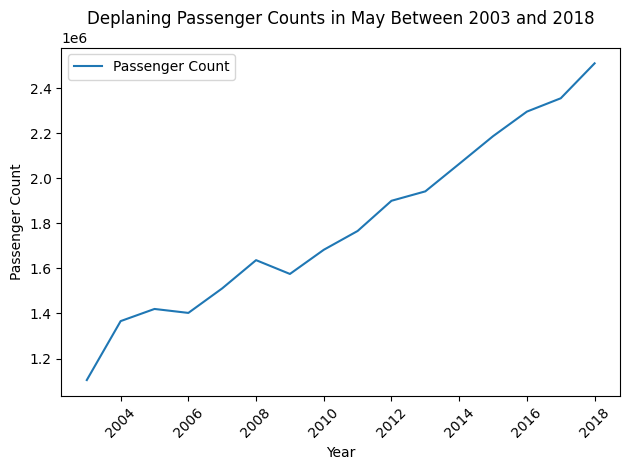

In [16]:
# visualize results
deplaned_in_may_df = deplaned_in_may_df[['Year','Passenger Count']].reset_index(drop=True)
deplaned_in_may_df.plot(x='Year', y='Passenger Count', kind='line')
plt.title("Deplaning Passenger Counts in May Between 2003 and 2018")
plt.xlabel("Year")
plt.ylabel("Passenger Count")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

Based on the visualization, the amount of deplaning passengers in May between 2003 and 2018 has steadily increased from just over 1 million in 2003 to around 2.5 million in 2018.

## Question 6: ##
TODO: Predict the passenger count for May 2019 and May 2020, using simple linear regression. Ensure that you visualize the original data and also include the predictions from the model. Compare the predicted passenger count with the actual passenger count. In your explanation, discuss how close/far your predictions are from the actual values.

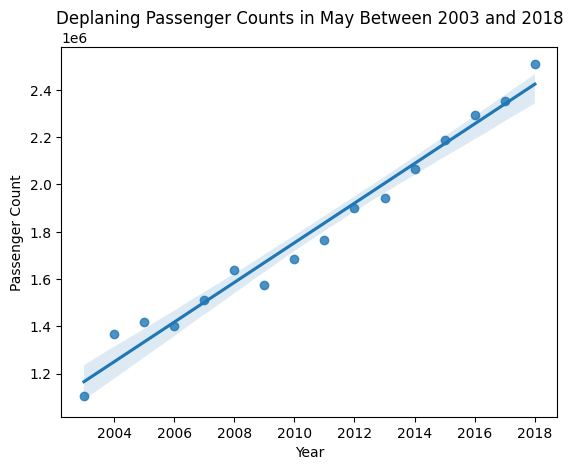

In [17]:
# visualize scatterplot and line of best fit
sns.regplot(data=deplaned_in_may_df, x='Year', y='Passenger Count')
plt.title("Deplaning Passenger Counts in May Between 2003 and 2018")
plt.show()

In [18]:
# fit simple linear regression model
X = deplaned_in_may_df['Year'].to_numpy()
X = X.reshape(-1, 1)

y = deplaned_in_may_df['Passenger Count'].to_numpy()
y = y.reshape(-1, 1)

lr_model = LinearRegression(fit_intercept=True)
lr_model = lr_model.fit(X, y)
slope = lr_model.coef_[0,0]
intercept = lr_model.intercept_[0]
print(f"slope: {slope}")
print(f"intercept: {intercept}")

slope: 83953.04999999996
intercept: -166992517.89999992


In [19]:
# predict passenger count for May 2019
passenger_count_2019 = np.array([2019]).reshape(-1, 1)
lr_model.predict(passenger_count_2019)

array([[2508690.05000001]])

In [20]:
# predict passenger count for May 2020
passenger_count_2020 = np.array([2020]).reshape(-1, 1)
lr_model.predict(passenger_count_2020)

array([[2592643.09999999]])

In [21]:
# compare predicted passenger count with actual passenger count

# calculate total deplanement passengers in 2019 and 2020
deplaned_in_may_df2 = yearly_df.copy()

# add month colum to data frame
deplaned_in_may_df2.loc[:, 'Month'] = deplaned_in_may_df2['Activity Period Start Date'].dt.month


# create filter for data frame
deplaned_in_may_filter2 = (((deplaned_in_may_df2['Year'] == 2019) 
                          | (deplaned_in_may_df2['Year'] == 2020))
                          & (deplaned_in_may_df2['Month'] == 5)
                          & (deplaned_in_may_df2['Activity Type Code'].astype('string') == "Deplaned"))

# apply filter and sum total deplanement passengers by month
deplaned_in_may_df2 = deplaned_in_may_df2[deplaned_in_may_filter2]
deplaned_in_may_df2 = deplaned_in_may_df2.groupby(['Year', 'Month'], observed=True)['Passenger Count'].sum().reset_index()
deplaned_in_may_df2.head()

,Year,Month,Passenger Count
0,2019,5,2494705
1,2020,5,141789


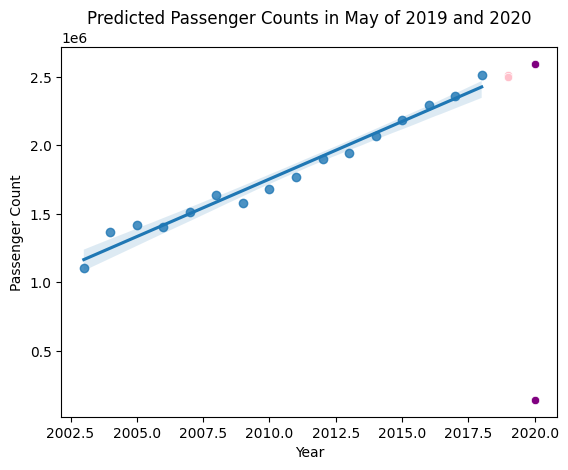

In [22]:
# extract actual passenger counts for 2019 and 2020
act_2019 = deplaned_in_may_df2.loc[0, 'Passenger Count']
act_2020 = deplaned_in_may_df2.loc[1, 'Passenger Count']

# visualize actual and predicted values
fig = plt.figure()
sns.regplot(data=deplaned_in_may_df, x='Year', y='Passenger Count')
sns.scatterplot(x=[2019], y=[2508690], color='pink')
sns.scatterplot(x=[2019], y=[act_2019], color='pink')
sns.scatterplot(x=[2020], y=[2592643], color='purple')
sns.scatterplot(x=[2020], y=[act_2020], color='purple')
plt.title("Predicted Passenger Counts in May of 2019 and 2020")
plt.show()

Based on the visualization, the predicted passenger count for 2019 was accurate as shown by the pink points in the scatterplot.  In 2019, there was just under 2.5 million passengers in May.  However, the predicted passenger count for 2020 was not accurate as shown by the purple points in the scatterplot.  While the predicted count for 2020 based on the model was just over 2.5 million, the actual count was 141,789.  This deviation was likely due to the impact of global travel restrictions during the COVID-19 pandemic.

## Question 7: ##
TODO: Calculate the R-squared and explain what this tells you about the model.

In [23]:
# calculate R-squared
y_pred = slope * X + intercept
y_pred = y_pred.flatten()

y = y.flatten()

r_squared = r2_score(y, y_pred)
print(f"R^2: {r_squared}")

R^2: 0.9752278415725478


Based on the R^2 value of about 97.5%, the linear regression model fits the given data on deplaned passenger counts in May between 2003 and 2018 well.  This indicates that variation in the amount of deplaned passengers is accounted by the model's predictions to a high degree.

## Question 8.1 (Challenge): ##
TODO: Visualize the residuals of the regression model in question 6 and explain the chart.

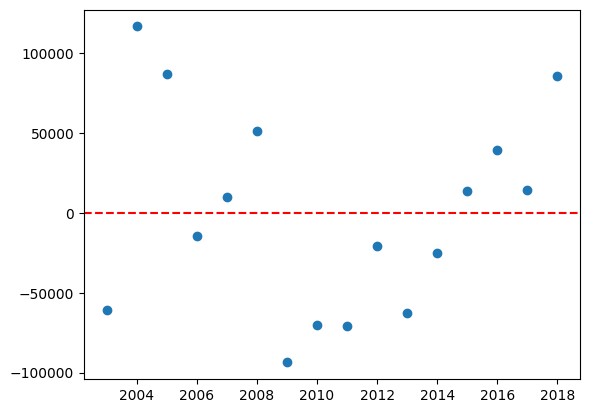

In [24]:
# calculate residuals
residuals = y - y_pred
plt.scatter(X, residuals)
plt.axhline(y=0, color='r', linestyle='--')
plt.show()

Based on the visualization, it can be determined that the model tends to underpredict the number of deplaned passengers in early years from 2004 to 2008 as well as later years from 2015 to 2018 based on the positive residual values.  The model also tends to overpredict the number of deplaned passengers between 2009 and 2014 based on the negative residual values.  Some of the larger residual values such as in 2004 and between 2009 and 2013 may also affect the accuracy of the model.